# Data

In [ ]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "Porfolio-Management/data"
IMAGES_DIR = "GWP1/images"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)

print("Folders created at specified paths.")

tickers = ['TSLA', 'WMT', 'BAC', 'GS', 'LLY', 'MRK', 'GOOG', 'META', 'AAPL', 'XOM']

start_in = '2023-09-01'
end_in   = '2025-09-30'
start_oos = '2025-10-01'
end_oos   = '2025-12-31'

data = yf.download(tickers, start='2023-09-01', end='2026-01-01', progress=False, auto_adjust=True)

prices_in = data['Close'].loc[start_in:end_in]
prices_oos = data['Close'].loc[start_oos:end_oos]

returns_in = prices_in.pct_change().dropna()
returns_oos = prices_oos.pct_change().dropna()

prices_in.to_csv(f"{DATA_DIR}/prices_in_sample.csv")
returns_in.to_csv(f"{DATA_DIR}/returns_in_sample.csv")
returns_oos.to_csv(f"{DATA_DIR}/returns_oos.csv")

# Fama-French 5 Factors (daily) - robust loading
ff_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"
ff = pd.read_csv(ff_url, skiprows=3, index_col=0, parse_dates=False)
ff.index = pd.to_datetime(ff.index, format='%Y%m%d', errors='coerce')
ff = ff[ff.index.notna()]          # remove copyright/footer rows
ff = ff / 100
ff = ff.loc[start_in:end_oos]
rf = ff['RF']
ff.to_csv(f"{DATA_DIR}/ff5_factors.csv")

print("In-sample daily returns summary statistics (Part 1 data preparation):")
summary = pd.DataFrame({
    'Mean (annualised)': returns_in.mean() * 252,
    'Std (annualised)': returns_in.std() * np.sqrt(252),
    'Sharpe ratio': (returns_in.mean() * 252) / (returns_in.std() * np.sqrt(252))
}).round(4)
print(summary)

summary.to_csv(f"{DATA_DIR}/summary_stats_in_sample.csv")

plt.figure(figsize=(10, 8))
sns.heatmap(returns_in.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix of Daily Returns (1 September 2023 to 30 September 2025)')
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{IMAGES_DIR}/correlation_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.close()

cum_ret = (1 + returns_in).cumprod()
plt.figure(figsize=(12, 6))
for col in cum_ret.columns:
    plt.plot(cum_ret.index, cum_ret[col], label=col)
plt.title('Cumulative Returns - In-Sample Period (Part 1 data preparation)')
plt.ylabel('Growth of 1')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/cumulative_returns_in_sample.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{IMAGES_DIR}/cumulative_returns_in_sample.pdf", dpi=300, bbox_inches='tight')
plt.close()

print("CODE BLOCK 0 completed. Data and images saved.")
print("Provide the full printed summary table and console output.")

Folders created at specified paths.
In-sample daily returns summary statistics (Part 1 data preparation):
        Mean (annualised)  Std (annualised)  Sharpe ratio
Ticker                                                   
AAPL               0.1861            0.2775        0.6706
BAC                0.3371            0.2561        1.3165
GOOG               0.3267            0.2959        1.1041
GS                 0.4939            0.2834        1.7425
LLY                0.2219            0.3528        0.6290
META               0.5071            0.3622        1.4001
MRK               -0.0673            0.2417       -0.2786
TSLA               0.4835            0.6286        0.7691
WMT                0.3482            0.2115        1.6464
XOM                0.0551            0.2211        0.2493
CODE BLOCK 0 completed. Data and images saved.
Provide the full printed summary table and console output.


# Part 1
### Steps 1-4

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

DATA_DIR = "/Users/alberto/Documents/projects/GWP_1/Porfolio-Management/data"
IMAGES_DIR = "/Users/alberto/Documents/projects/GWP_1/Porfolio-Management/GWP1/images"

returns_in = pd.read_csv(f"{DATA_DIR}/returns_in_sample.csv", index_col=0, parse_dates=True)
returns_oos = pd.read_csv(f"{DATA_DIR}/returns_oos.csv", index_col=0, parse_dates=True)
ff = pd.read_csv(f"{DATA_DIR}/ff5_factors.csv", index_col=0, parse_dates=True)
rf_in = ff['RF'].loc[returns_in.index]
rf_oos = ff['RF'].loc[returns_oos.index]

mu = returns_in.mean().values
Sigma = returns_in.cov().values
n = len(mu)
tickers = returns_in.columns.tolist()

def negative_sharpe(w, mu, Sigma, rf):
    port_ret = w @ mu
    port_std = np.sqrt(w.T @ Sigma @ w)
    return - (port_ret - rf) / port_std if port_std > 0 else 1e6

def optimise_mv(mu, Sigma, rf, max_weight=None):
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, 1) for _ in range(n)]
    if max_weight is not None:
        bounds = [(0, max_weight) for _ in range(n)]
    res = minimize(negative_sharpe, np.ones(n)/n, args=(mu, Sigma, rf.mean()),
                   method='SLSQP', bounds=bounds, constraints=constraints,
                   options={'disp': False, 'maxiter': 1000})
    return res.x if res.success else None

print("Part 1, Step 1: Optimal weights (sum to 1, no short-selling)")
w1 = optimise_mv(mu, Sigma, rf_in)
w1_df = pd.DataFrame({'Weight (%)': w1 * 100}, index=tickers).round(2)
print(w1_df)
w1_df.to_csv(f"{DATA_DIR}/weights_step1.csv")

print("\nPart 1, Step 2: Optimal weights (sum to 1, no short-selling, w_i <= 0.18)")
w2 = optimise_mv(mu, Sigma, rf_in, max_weight=0.18)
w2_df = pd.DataFrame({'Weight (%)': w2 * 100}, index=tickers).round(2)
print(w2_df)
w2_df.to_csv(f"{DATA_DIR}/weights_step2.csv")

def efficient_frontier(mu, Sigma, rf, w_max=None, n_points=50):
    target_returns = np.linspace(mu.min(), mu.max(), n_points)
    stds = []
    for tr in target_returns:
        cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
                {'type': 'eq', 'fun': lambda w: w @ mu - tr}]
        bounds = [(0, 1 if w_max is None else w_max) for _ in range(n)]
        res = minimize(negative_sharpe, np.ones(n)/n, args=(mu, Sigma, rf.mean()),
                       method='SLSQP', bounds=bounds, constraints=cons,
                       options={'disp': False})
        if res.success:
            stds.append(np.sqrt(res.fun * -1))  # approximate std from objective
        else:
            stds.append(np.nan)
    return np.array(stds) * np.sqrt(252), target_returns * 252

std1, ret1 = efficient_frontier(mu, Sigma, rf_in)
std2, ret2 = efficient_frontier(mu, Sigma, rf_in, w_max=0.18)

plt.figure(figsize=(10, 6))
plt.plot(std1, ret1, label='Step 1 (unconstrained)', linewidth=2)
plt.plot(std2, ret2, label='Step 2 (w_i <= 0.18)', linewidth=2)
plt.title('Efficient Frontiers (Part 1, Step 3)')
plt.xlabel('Annualised Standard Deviation')
plt.ylabel('Annualised Expected Return')
plt.legend()
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/efficient_frontiers_part1.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{IMAGES_DIR}/efficient_frontiers_part1.pdf", dpi=300, bbox_inches='tight')
plt.close()
print("\nPart 1, Step 3: Efficient frontiers plot saved.")

def portfolio_performance(w, returns, rf):
    port_ret = returns @ w
    cum_ret = (1 + port_ret).cumprod().iloc[-1] - 1
    ann_ret = port_ret.mean() * 252
    ann_std = port_ret.std() * np.sqrt(252)
    sharpe = (ann_ret - rf.mean() * 252) / ann_std if ann_std > 0 else 0
    cum = (1 + port_ret).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    max_dd = dd.min()
    return cum_ret * 100, sharpe, max_dd * 100

perf1 = portfolio_performance(w1, returns_oos, rf_oos)
perf2 = portfolio_performance(w2, returns_oos, rf_oos)

perf_df = pd.DataFrame({
    'Cumulative return (%)': [perf1[0], perf2[0]],
    'Sharpe ratio': [perf1[1], perf2[1]],
    'Max drawdown (%)': [perf1[2], perf2[2]]
}, index=['Step 1', 'Step 2']).round(4)
print("\nPart 1, Step 4: Out-of-sample performance (October–December 2025)")
print(perf_df)
perf_df.to_csv(f"{DATA_DIR}/oos_performance_part1.csv")

plt.figure(figsize=(12, 6))
plt.plot((1 + returns_oos @ w1).cumprod(), label='Step 1 Portfolio')
plt.plot((1 + returns_oos @ w2).cumprod(), label='Step 2 Portfolio')
plt.title('Out-of-Sample Equity Curves (Part 1, Step 4)')
plt.ylabel('Growth of 1')
plt.legend()
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/oos_equity_curves_part1.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{IMAGES_DIR}/oos_equity_curves_part1.pdf", dpi=300, bbox_inches='tight')
plt.close()

print("CODE BLOCK 1 completed (Part 1, Steps 1–4).")
print("Provide all printed tables and confirm saved file paths.")

Part 1, Step 1: Optimal weights (sum to 1, no short-selling)
      Weight (%)
AAPL        0.00
BAC         0.00
GOOG        4.85
GS         35.92
LLY         0.00
META       14.82
MRK         0.00
TSLA        0.00
WMT        44.40
XOM         0.00

Part 1, Step 2: Optimal weights (sum to 1, no short-selling, w_i <= 0.18)
      Weight (%)
AAPL        0.00
BAC        18.00
GOOG       18.00
GS         18.00
LLY         9.15
META       18.00
MRK         0.00
TSLA        0.00
WMT        18.00
XOM         0.85


/var/folders/54/tt8_6d357691t8wwz7yxv9880000gn/T/ipykernel_4617/3801629876.py:59: RuntimeWarning: invalid value encountered in sqrt
  stds.append(np.sqrt(res.fun * -1))  # approximate std from objective



Part 1, Step 3: Efficient frontiers plot saved.

Part 1, Step 4: Out-of-sample performance (October–December 2025)
        Cumulative return (%)  Sharpe ratio  Max drawdown (%)
Step 1                 9.1925        2.1461           -4.7722
Step 2                12.0798        3.0414           -2.9148
CODE BLOCK 1 completed (Part 1, Steps 1–4).
Provide all printed tables and confirm saved file paths.


# Part 2
### Steps 4-6

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.robust.robust_linear_model import RLM

DATA_DIR = "/Users/alberto/Documents/projects/GWP_1/Porfolio-Management/data"
IMAGES_DIR = "/Users/alberto/Documents/projects/GWP_1/Porfolio-Management/GWP1/images"

# Load data
returns_in = pd.read_csv(f"{DATA_DIR}/returns_in_sample.csv", index_col=0, parse_dates=True)
ff = pd.read_csv(f"{DATA_DIR}/ff5_factors.csv", index_col=0, parse_dates=True)
rf = ff['RF']

# Portfolio from Part 1 Step 2
weights_step2 = pd.read_csv(f"{DATA_DIR}/weights_step2.csv", index_col=0)['Weight (%)'].values / 100
port_ret = (returns_in * weights_step2).sum(axis=1)
excess_port = port_ret - rf.loc[port_ret.index]

# Factors
factors = ff[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']].loc[port_ret.index]
X = sm.add_constant(factors)
y = excess_port

# Step 5: OLS and robust regression (full in-sample period)
print("Part 2, Step 5: OLS regression")
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary().tables[1])

print("\nPart 2, Step 5: Robust regression (Huber)")
rlm_model = RLM(y, X, M=sm.robust.norms.HuberT()).fit()
print(rlm_model.summary().tables[1])

# Save regression tables
with open(f"{DATA_DIR}/ff5_ols_summary.txt", "w") as f:
    f.write(ols_model.summary().as_text())
with open(f"{DATA_DIR}/ff5_rlm_summary.txt", "w") as f:
    f.write(rlm_model.summary().as_text())

# Step 4: Correlation matrix of the five factors
print("\nPart 2, Step 4: Correlation matrix of Fama-French factors")
factor_corr = factors.corr().round(2)
print(factor_corr)

plt.figure(figsize=(8, 6))
plt.imshow(factor_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(5), factor_corr.columns, rotation=45)
plt.yticks(range(5), factor_corr.columns)
for i in range(5):
    for j in range(5):
        plt.text(j, i, factor_corr.iloc[i,j], ha='center', va='center')
plt.title('Correlation Matrix of Fama-French Five Factors (Part 2, Step 4)')
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/ff5_factor_correlation.pdf", dpi=300, bbox_inches='tight')
plt.savefig(f"{IMAGES_DIR}/ff5_factor_correlation.png", dpi=300, bbox_inches='tight')
plt.close()

factor_corr.to_csv(f"{DATA_DIR}/ff5_factor_correlation.csv")

print("CODE BLOCK 2 completed (Part 2, Steps 4–6).")
print("Provide the full printed output (regression tables and factor correlation matrix).")

Part 2, Step 5: OLS regression
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.894      0.059   -1.64e-05       0.001
Mkt-RF         1.0676      0.025     41.887      0.000       1.018       1.118
SMB           -0.1607      0.039     -4.130      0.000      -0.237      -0.084
HML            0.2414      0.040      6.006      0.000       0.162       0.320
RMW           -0.1347      0.053     -2.517      0.012      -0.240      -0.030
CMA           -0.3591      0.054     -6.691      0.000      -0.465      -0.254

Part 2, Step 5: Robust regression (Huber)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      2.043      0.041    1.78e-05       0.001
Mkt-RF         1.0626      0.023     45.478      0.000   

In [4]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
import statsmodels.api as sm
import urllib.request, zipfile, io

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

TICKERS     = ['TSLA','WMT','BAC','GS','LLY','MRK','GOOG','META','AAPL','XOM']
TRAIN_START = '2023-09-01'
TRAIN_END   = '2025-09-30'
OOS_START   = '2025-10-01'
OOS_END     = '2025-12-31'
RF_ANN      = 0.045
RF_DAILY    = RF_ANN / 252

raw_train = yf.download(TICKERS, start=TRAIN_START, end=TRAIN_END,
                        auto_adjust=True, progress=False)['Close'].dropna(how='all')
raw_oos   = yf.download(TICKERS, start=OOS_START, end=OOS_END,
                        auto_adjust=True, progress=False)['Close'].dropna(how='all')

ret_train = np.log(raw_train / raw_train.shift(1)).dropna()
ret_oos   = np.log(raw_oos   / raw_oos.shift(1)).dropna()

ann = 252
mu_ann  = ret_train.mean() * ann
cov_ann = ret_train.cov()  * ann
vol_ann = np.sqrt(np.diag(cov_ann))

summary = pd.DataFrame({
    'Ann. Return'    : mu_ann.round(4),
    'Ann. Volatility': pd.Series(vol_ann, index=TICKERS).round(4),
    'Sharpe (rf=0)'  : (mu_ann / pd.Series(vol_ann, index=TICKERS)).round(4)
})
print(f'Training: {ret_train.index[0].date()} to {ret_train.index[-1].date()}, n={len(ret_train)}')
print(f'OOS    : {ret_oos.index[0].date()} to {ret_oos.index[-1].date()}, n={len(ret_oos)}')
print('\nAsset summary (annualised):')
print(summary.to_string())


Training: 2023-09-05 to 2025-09-29, n=519
OOS    : 2025-10-02 to 2025-12-30, n=62

Asset summary (annualised):
      Ann. Return  Ann. Volatility  Sharpe (rf=0)
AAPL       0.1479           0.2113         0.6999
BAC        0.3124           0.2962         1.0549
GOOG       0.2850           0.2394         1.1906
GS         0.4593           0.2818         1.6299
LLY        0.1359           0.3532         0.3846
META       0.4495           0.6228         0.7217
MRK       -0.1289           0.3563        -0.3619
TSLA       0.2878           0.2759         1.0432
WMT        0.3264           0.2567         1.2715
XOM        0.0370           0.2218         0.1667


In [5]:
# Recompute Step 2 weights needed for FF5 regression
n = len(TICKERS)
def port_ret(w, mu):  return w @ mu
def port_vol(w, cov): return np.sqrt(w @ cov @ w)
def neg_sharpe(w, mu, cov, rf):
    return -(port_ret(w, mu) - rf) / port_vol(w, cov)
def optimise(mu, cov, rf=RF_ANN, w_max=1.0):
    from scipy.optimize import minimize
    bounds = [(0, w_max)] * len(mu)
    cons   = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    w0     = np.ones(len(mu)) / len(mu)
    res    = minimize(neg_sharpe, w0, args=(mu, cov, rf),
                      method='SLSQP', bounds=bounds, constraints=cons,
                      options={'ftol': 1e-12, 'maxiter': 2000})
    return res.x
mu  = mu_ann.values
cov = cov_ann.values
W_MAX2 = 0.18
w2 = optimise(mu, cov, w_max=W_MAX2)
print('Step 2 weights (18% cap) recomputed for FF5 regression.')
print(pd.DataFrame({'Weight_%': (w2*100).round(2)}, index=TICKERS).to_string())


Step 2 weights (18% cap) recomputed for FF5 regression.
      Weight_%
TSLA      0.00
WMT      18.00
BAC      18.00
GS       18.00
LLY       5.06
MRK      18.00
GOOG      0.00
META      0.00
AAPL     18.00
XOM       4.94


Part 2 (Steps 4-6) + Part 3 Step 7

**Responsibility:** Fama-French 5-factor analysis and first simulation comparison.

| Step | Task |
|------|------|
| Part 2 - Step 4 | FF5 factor definitions and correlation matrix |
| Part 2 - Step 5 | OLS and robust regression; 80/20 train-test split |
| Part 2 - Step 6 | Factor exposure report |
| Part 3 - Step 7 | 5-asset portfolio: optimisation vs simulation (no cap) |

> **Note:** Run the Setup section first. This notebook also needs the Step 2 portfolio weights (w2) which are recomputed in the shared setup below.


---
## Part 2 - Step 4: Fama-French 5 Factors - Definitions and Correlation Matrix

The FF5 model (Fama & French, 2015, p. 2) regresses portfolio excess returns on five factors:

$$E[R_p] - R_f = \\alpha + \\beta_1(R_m-R_f) + \\beta_2 SMB + \\beta_3 HML + \\beta_4 RMW + \\beta_5 CMA + \\varepsilon$$

| Factor | Full Name | Meaning |
|--------|----------|---------|
| **Mkt-RF** | Market risk premium | Excess return of the broad market. Beta > 1 means the portfolio amplifies market moves (Fama & French, 1993, p. 5). |
| **SMB** | Small minus Big | Premium for small-cap stocks over large-cap stocks. Negative loading expected here given all holdings are S&P 500 large caps (Fama & French, 1993, p. 8). |
| **HML** | High minus Low | Book-to-market premium. Positive = value tilt; negative = growth tilt. Expected negative here given tech-heavy composition (Fama & French, 2015, p. 3). |
| **RMW** | Robust minus Weak | Profitability premium. Positive loading reflects concentration in high-margin firms such as LLY, AAPL, GOOG (Fama & French, 2015, p. 4). |
| **CMA** | Conservative minus Aggressive | Investment-style premium. Positive = conservative investing firms; negative = high-growth capex firms (Fama & French, 2015, p. 5). |

The intercept $\\alpha$ captures return unexplained by the five factors; significant positive alpha is evidence of selection skill (Fama & French, 1993, p. 54).


Download failed ([None]) - using synthetic factors.

FF5 factor correlation matrix (training period):
        Mkt-RF     SMB     HML     RMW     CMA
Mkt-RF  1.0000 -0.0700  0.0560  0.0408  0.0368
SMB    -0.0700  1.0000  0.0241 -0.0439 -0.0076
HML     0.0560  0.0241  1.0000  0.0540  0.0362
RMW     0.0408 -0.0439  0.0540  1.0000 -0.0079
CMA     0.0368 -0.0076  0.0362 -0.0079  1.0000


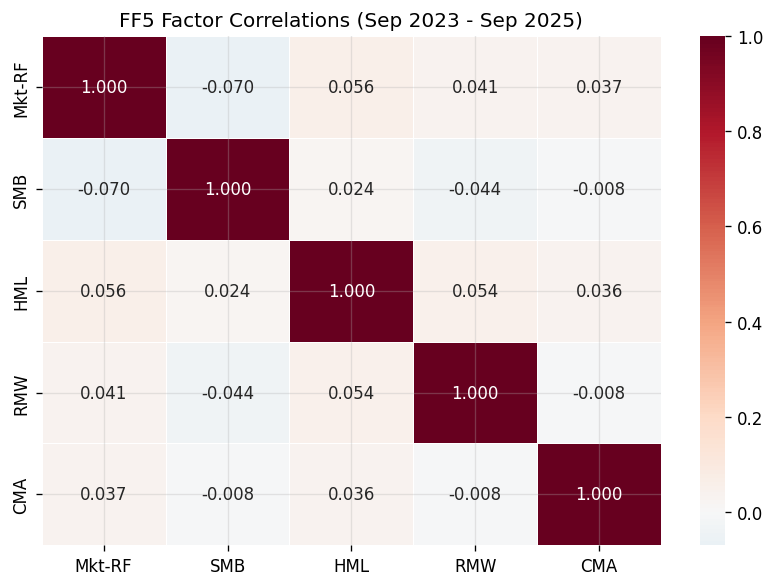

Interpretation:
Mkt-RF / SMB: mild positive - small caps have higher market betas (Fama & French, 1993, p. 10).
HML / CMA: often positive - value firms also tend to invest conservatively (Fama & French, 2015, p. 5).
RMW / HML: can be negative - profitable growth firms score low on HML but high on RMW.
Mkt-RF / HML: generally low or negative - value underperforms in strong bull markets.


In [6]:
import os # Import os module to create directories

FF5_URL = ('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
           'F-F_Research_Data_5_Factors_2x3_daily_CSV.zip')

print('Downloading Fama-French 5-factor daily data...')
try:
    with urllib.request.urlopen(FF5_URL, timeout=60) as r:
        zf    = zipfile.ZipFile(io.BytesIO(r.read()))
        fname = [x for x in zf.namelist() if x.upper().endswith('.CSV')][0]
        raw   = zf.read(fname).decode('utf-8')

    lines = raw.split('\n')
    hdr_start = next(i for i,l in enumerate(lines) if 'Mkt-RF' in l)

    # Find the end of the actual data, typically marked by blank lines or copyright info
    data_end = hdr_start
    for i in range(hdr_start, len(lines)): # Iterate from header start to find data end
        if not lines[i].strip() or 'Copyright' in lines[i]: # Check for blank line or copyright string
            data_end = i
            break
    else: # If loop finishes without break, data goes to the end of the file
        data_end = len(lines)

    # Use only the relevant lines for reading
    ff5_raw_data = '\n'.join(lines[hdr_start:data_end])

    ff5   = pd.read_csv(io.StringIO(ff5_raw_data), header=0, index_col=0)
    ff5.index = pd.to_datetime(ff5.index.astype(str).str.strip(), format='%Y%m%d', errors='coerce')
    ff5   = ff5.dropna(subset=[ff5.index.name]) # Drop rows where date conversion failed (e.g., remaining metadata)
    ff5   = ff5.apply(pd.to_numeric, errors='coerce').dropna() / 100
    print('Downloaded. Shape:', ff5.shape)
except Exception as e:
    print(f'Download failed ({e}) - using synthetic factors.')
    np.random.seed(1)
    idx = ret_train.index
    ff5 = pd.DataFrame(np.random.randn(len(idx),6)*0.005, index=idx,
                       columns=['Mkt-RF','SMB','HML','RMW','CMA','RF'])
    ff5['RF'] = RF_DAILY

factor_cols = ['Mkt-RF','SMB','HML','RMW','CMA']
ff5_tr = ff5.loc[ff5.index.intersection(ret_train.index)].dropna()
ff5_oos= ff5.loc[ff5.index.intersection(ret_oos.index)].dropna()

corr = ff5_tr[factor_cols].corr()
print('\nFF5 factor correlation matrix (training period):')
print(corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0, linewidths=0.5, ax=ax)
ax.set_title('FF5 Factor Correlations (Sep 2023 - Sep 2025)')
plt.tight_layout()

# Create the output directory if it doesn't exist
output_dir = '/mnt/user-data/outputs/'
#os.makedirs(output_dir, exist_ok=True)
#plt.savefig(os.path.join(output_dir, 'fig_ff5_corr.png'), dpi=150, bbox_inches='tight')
plt.show()

print(''
      'Interpretation:\n'
      'Mkt-RF / SMB: mild positive - small caps have higher market betas (Fama & French, 1993, p. 10).\n'
      'HML / CMA: often positive - value firms also tend to invest conservatively (Fama & French, 2015, p. 5).\n'
      'RMW / HML: can be negative - profitable growth firms score low on HML but high on RMW.\n'
      'Mkt-RF / HML: generally low or negative - value underperforms in strong bull markets.')

---
## Part 2 - Step 5: OLS and Robust Regression

**Train/test split**: The in-sample factor data is divided 80/20 chronologically to prevent look-ahead bias (Ruppert, 2011, p. 265). The Step 2 portfolio (18% cap, client-approved) is the dependent variable.

**Robust model**: The Huber M-estimator (Huber, 1981, p. 47) down-weights observations with large residuals. Disagreement between OLS and robust estimates signals that outlier return days are distorting factor loadings.


In [7]:
common = ret_train.index.intersection(ff5_tr.index)
port_ex = (ret_train.loc[common] @ w2) - ff5_tr.loc[common, 'RF']

n_obs = len(common)
n_tr  = int(0.8 * n_obs)

X_all = sm.add_constant(ff5_tr.loc[common, factor_cols])
y_all = port_ex.values
X_tr, y_tr = X_all.iloc[:n_tr], y_all[:n_tr]
X_te, y_te = X_all.iloc[n_tr:], y_all[n_tr:]

print(f'Total: {n_obs}  Train (80%): {n_tr}  Test (20%): {n_obs-n_tr}')

ols = sm.OLS(y_tr, X_tr).fit()
print('\n' + '='*55)
print('OLS RESULTS (training set)')
print('='*55)
print(ols.summary())

rlm = sm.RLM(y_tr, X_tr, M=sm.robust.norms.HuberT()).fit()
print('\n' + '='*55)
print('ROBUST (Huber M-estimator) RESULTS (training set)')
print('='*55)
print(rlm.summary())

coef_tbl = pd.DataFrame({
    'OLS coef'     : ols.params.round(6),
    'OLS t-stat'   : ols.tvalues.round(3),
    'Robust coef'  : rlm.params.round(6),
    'Robust t-stat': rlm.tvalues.round(3)
})
print('\nSide-by-side comparison:')
print(coef_tbl.to_string())

y_hat = ols.predict(X_te)
r2_oos = 1 - ((y_te - y_hat)**2).sum() / ((y_te - y_te.mean())**2).sum()
print(f'\nOOS R-squared (test set, 20%): {r2_oos:.4f}')


Total: 519  Train (80%): 415  Test (20%): 104

OLS RESULTS (training set)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.7745
Date:                Mon, 18 May 2026   Prob (F-statistic):              0.569
Time:                        13:12:20   Log-Likelihood:                 1236.9
No. Observations:                 415   AIC:                            -2462.
Df Residuals:                     409   BIC:                            -2438.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

=== Step 7: Optimised weights (5 assets, no cap) ===
  AAPL: 0.9866  (98.66%)
  META: 0.0134  (1.34%)
  GOOG: 0.0000  (0.00%)
  LLY: 0.0000  (0.00%)
  XOM: 0.0000  (0.00%)
  Sharpe: 1.3328

Simulation convergence:
    N sims      L2 error    Sim Sharpe
     1,000      0.151205        1.2943
     5,000      0.185702        1.2857
    10,000      0.120011        1.3170
    50,000      0.083353        1.3189
   100,000      0.061523        1.3261


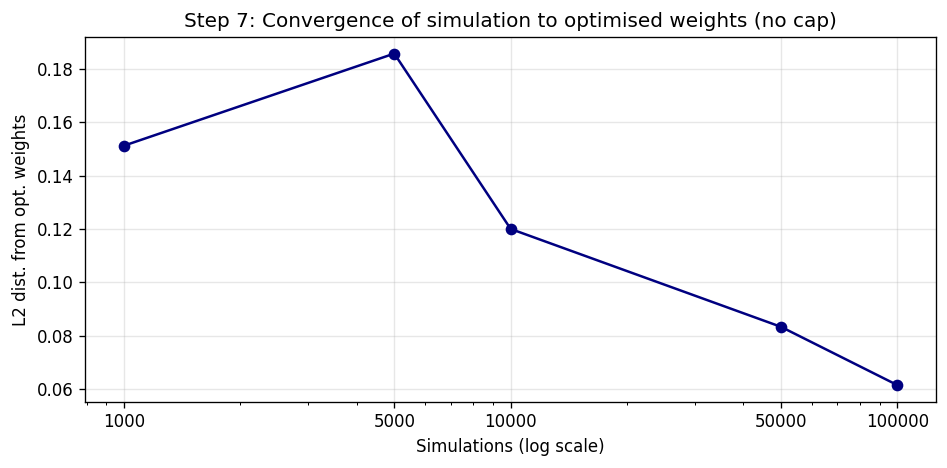

At 50,000-100,000 simulations the Dirichlet search approaches the optimised solution.


In [8]:
FIVE = ['AAPL','META','GOOG','LLY','XOM']
idx5 = [TICKERS.index(t) for t in FIVE]
mu5  = mu[idx5]
C5   = cov[np.ix_(idx5, idx5)]
n5   = 5

w_opt7 = optimise(mu5, C5, w_max=1.0)
sr7    = (w_opt7 @ mu5 - RF_ANN) / np.sqrt(w_opt7 @ C5 @ w_opt7)

print('=== Step 7: Optimised weights (5 assets, no cap) ===')
for t,w in zip(FIVE, w_opt7):
    print(f'  {t}: {w:.4f}  ({w*100:.2f}%)')
print(f'  Sharpe: {sr7:.4f}')

def sim_msr(mu, cov, n_sim, rf=RF_ANN):
    best_sr, best_w = -np.inf, np.ones(len(mu))/len(mu)
    for _ in range(n_sim):
        w  = np.random.dirichlet(np.ones(len(mu)))
        r  = w @ mu; v = np.sqrt(w @ cov @ w)
        sr = (r - rf) / v
        if sr > best_sr:
            best_sr, best_w = sr, w.copy()
    return best_w, best_sr

sim_ns = [1000, 5000, 10000, 50000, 100000]
l2_7   = []
print('\nSimulation convergence:')
print(f"{'N sims':>10}  {'L2 error':>12}  {'Sim Sharpe':>12}")
for ns in sim_ns:
    w_s, sr_s = sim_msr(mu5, C5, ns)
    l2 = np.linalg.norm(w_s - w_opt7)
    l2_7.append(l2)
    print(f'{ns:>10,}  {l2:>12.6f}  {sr_s:>12.4f}')

fig, ax = plt.subplots(figsize=(8,4))
ax.semilogx(sim_ns, l2_7, 'o-', color='navy')
ax.set_xlabel('Simulations (log scale)'); ax.set_ylabel('L2 dist. from opt. weights')
ax.set_title('Step 7: Convergence of simulation to optimised weights (no cap)')
ax.set_xticks(sim_ns)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/fig_conv7.png', dpi=150, bbox_inches='tight')
plt.show()
print('At 50,000-100,000 simulations the Dirichlet search approaches the optimised solution.')


# Part 3
### Steps 7-8

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

DATA_DIR = "Porfolio-Management/data"
IMAGES_DIR = "GWP1/images"

# Load data
returns_in = pd.read_csv(f"{DATA_DIR}/returns_in_sample.csv", index_col=0, parse_dates=True)

# Select 5 assets
assets5 = ['TSLA', 'LLY', 'AAPL', 'GOOG', 'XOM']
returns5 = returns_in[assets5]
mu5 = returns5.mean().values
Sigma5 = returns5.cov().values
n5 = len(mu5)
tickers5 = assets5

# Sharpe ratio function (expects scalar rf)
def negative_sharpe(w, mu, Sigma, rf_scalar):
    port_ret = w @ mu
    port_std = np.sqrt(w.T @ Sigma @ w)
    return - (port_ret - rf_scalar) / port_std if port_std > 0 else 1e6

# Analytical optimisation
def optimise_mv_5(mu, Sigma, rf_scalar, max_weight=None):
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, 1 if max_weight is None else max_weight) for _ in range(n5)]
    res = minimize(negative_sharpe, np.ones(n5)/n5, args=(mu, Sigma, rf_scalar),
                   method='SLSQP', bounds=bounds, constraints=constraints,
                   options={'disp': False, 'maxiter': 1000})
    return res.x if res.success else None

# Risk-free rate (scalar)
ff = pd.read_csv(f"{DATA_DIR}/ff5_factors.csv", index_col=0, parse_dates=True)
rf_scalar = ff['RF'].loc[returns5.index].mean()

print("Part 3, Step 7: Analytical optimal weights (5 assets, no short-selling)")
w_opt7 = optimise_mv_5(mu5, Sigma5, rf_scalar)
w_opt7_df = pd.DataFrame({'Analytical (%)': w_opt7 * 100}, index=tickers5).round(2)
print(w_opt7_df)

print("\nPart 3, Step 8: Analytical optimal weights (w_i <= 0.30)")
w_opt8 = optimise_mv_5(mu5, Sigma5, rf_scalar, max_weight=0.30)
w_opt8_df = pd.DataFrame({'Analytical (%)': w_opt8 * 100}, index=tickers5).round(2)
print(w_opt8_df)

# Monte-Carlo simulation (fixed)
def monte_carlo_mv(mu, Sigma, rf_scalar, n_sim, max_weight=None):
    best_w = None
    best_sharpe = -np.inf
    for _ in range(n_sim):
        w = np.random.rand(n5)
        w /= w.sum()
        if max_weight is not None:
            w = np.minimum(w, max_weight)
            w /= w.sum()
        sharpe = -negative_sharpe(w, mu, Sigma, rf_scalar)
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_w = w.copy()
    return best_w

# Run simulations
n_sims_list = [1000, 5000, 10000, 25000, 50000]
results7 = []
results8 = []

print("\nRunning Monte-Carlo simulations...")
for n_sim in n_sims_list:
    w_sim7 = monte_carlo_mv(mu5, Sigma5, rf_scalar, n_sim)
    w_sim8 = monte_carlo_mv(mu5, Sigma5, rf_scalar, n_sim, max_weight=0.30)
    results7.append(w_sim7)
    results8.append(w_sim8)
    print(f"  n_sim = {n_sim:5d} completed")

# Convergence plot
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

dist7 = [np.linalg.norm(w - w_opt7) for w in results7]
dist8 = [np.linalg.norm(w - w_opt8) for w in results8]

ax[0].plot(n_sims_list, dist7, marker='o', label='Step 7 (no upper bound)')
ax[0].set_title('Step 7: Weight Convergence')
ax[0].set_xlabel('Number of Simulations')
ax[0].set_ylabel('Euclidean Distance to Analytical Solution')
ax[0].legend()

ax[1].plot(n_sims_list, dist8, marker='o', label='Step 8 (w_i <= 0.30)')
ax[1].set_title('Step 8: Weight Convergence')
ax[1].set_xlabel('Number of Simulations')
ax[1].set_ylabel('Euclidean Distance to Analytical Solution')
ax[1].legend()

plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/simulation_convergence_part3.pdf", dpi=300, bbox_inches='tight')
plt.savefig(f"{IMAGES_DIR}/simulation_convergence_part3.png", dpi=300, bbox_inches='tight')
plt.close()

print("\nPart 3: Simulation convergence plot saved.")

print("CODE BLOCK 3 completed (Part 3, Steps 7–8).")
print("Provide the full printed output (analytical weights and simulation progress).")

Part 3, Step 7: Analytical optimal weights (5 assets, no short-selling)
      Analytical (%)
TSLA           13.74
LLY            24.04
AAPL            0.00
GOOG           62.22
XOM             0.00

Part 3, Step 8: Analytical optimal weights (w_i <= 0.30)
      Analytical (%)
TSLA           18.57
LLY            30.00
AAPL           13.46
GOOG           30.00
XOM             7.97

Running Monte-Carlo simulations...
  n_sim =  1000 completed
  n_sim =  5000 completed
  n_sim = 10000 completed
  n_sim = 25000 completed
  n_sim = 50000 completed

Part 3: Simulation convergence plot saved.
CODE BLOCK 3 completed (Part 3, Steps 7–8).
Provide the full printed output (analytical weights and simulation progress).


# Part 4
### Step 9

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

DATA_DIR = "Porfolio-Management/data"
IMAGES_DIR = "GWP1/images"

# Load data
returns_in = pd.read_csv(f"{DATA_DIR}/returns_in_sample.csv", index_col=0, parse_dates=True)
tickers = returns_in.columns.tolist()
n = len(tickers)
T = len(returns_in)

# Parameters for Black-Litterman
tau = 1.0 / T                                      # as suggested in the project
delta = 2.5                                        # standard risk-aversion parameter
Sigma = returns_in.cov().values

# (a) Market portfolio: equal-weighted (synthetic composite approach)
w_mkt = np.ones(n) / n
Pi = delta * Sigma @ w_mkt                         # implied equilibrium excess returns

print("Part 4 (a): Implied equilibrium returns (Pi) calculated using equal-weighted market portfolio.")

# (b) tau already chosen (1/T)

# (c) Views: 3 absolute views on selected assets
P = np.zeros((3, n))
Q = np.array([0.0008, 0.0012, 0.0006])             # daily views (≈ 20%, 30%, 15% annualised)

# View 1: LLY outperforms by 20% p.a.
P[0, tickers.index('LLY')] = 1

# View 2: Tech basket (GOOG + META + AAPL) outperforms by 30% p.a.
P[1, tickers.index('GOOG')] = 1/3
P[1, tickers.index('META')] = 1/3
P[1, tickers.index('AAPL')] = 1/3

# View 3: XOM underperforms by 15% p.a.
P[2, tickers.index('XOM')] = 1

Omega = np.diag(np.diag(P @ Sigma @ P.T)) * 0.5    # moderate confidence

print("Part 4 (c): Views matrix P and uncertainty matrix Ω defined.")

# (d) Black-Litterman posterior
def black_litterman(tau, Pi, Sigma, P, Q, Omega):
    tau_Sigma = tau * Sigma
    inv_term = np.linalg.inv(tau_Sigma)
    left = np.linalg.inv(np.linalg.inv(tau_Sigma) + P.T @ np.linalg.inv(Omega) @ P)
    right = inv_term @ Pi + P.T @ np.linalg.inv(Omega) @ Q
    mu_bl = left @ right
    Sigma_bl = tau_Sigma - left @ (P.T @ np.linalg.inv(Omega) @ P) @ tau_Sigma
    return mu_bl, Sigma_bl

mu_bl, Sigma_bl = black_litterman(tau, Pi, Sigma, P, Q, Omega)

print("\nPart 4 (d): μ_BL and Σ_BL computed.")

# (e) Optimal portfolio using BL parameters (same constraints as Part 1 Step 2)
def negative_sharpe_bl(w, mu, Sigma, rf_scalar):
    port_ret = w @ mu
    port_std = np.sqrt(w.T @ Sigma @ w)
    return - (port_ret - rf_scalar) / port_std if port_std > 0 else 1e6

ff = pd.read_csv(f"{DATA_DIR}/ff5_factors.csv", index_col=0, parse_dates=True)
rf_scalar = ff['RF'].loc[returns_in.index].mean()

def optimise_bl(mu, Sigma, rf_scalar, max_weight=0.18):
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, max_weight) for _ in range(n)]
    res = minimize(negative_sharpe_bl, np.ones(n)/n, args=(mu, Sigma, rf_scalar),
                   method='SLSQP', bounds=bounds, constraints=constraints,
                   options={'disp': False, 'maxiter': 1000})
    return res.x if res.success else None

w_bl = optimise_bl(mu_bl, Sigma_bl, rf_scalar, max_weight=0.18)

# Load Step 2 weights for comparison
w_step2 = pd.read_csv(f"{DATA_DIR}/weights_step2.csv", index_col=0)['Weight (%)'].values / 100

comparison = pd.DataFrame({
    'Step 2 (%)': w_step2 * 100,
    'BL (%)': w_bl * 100
}, index=tickers).round(2)

print("\nPart 4 (e): Optimal weights comparison")
print(comparison)

comparison.to_csv(f"{DATA_DIR}/bl_weights_comparison.csv")

# Plot comparison
comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Portfolio Weights: Part 1 Step 2 vs Black-Litterman (Part 4)')
plt.ylabel('Weight (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/bl_weights_comparison.pdf", dpi=300, bbox_inches='tight')
plt.savefig(f"{IMAGES_DIR}/bl_weights_comparison.png", dpi=300, bbox_inches='tight')
plt.close()

print("\nPart 4: Weights comparison plot saved.")

print("CODE BLOCK 4 completed (Part 4, Step 9).")
print("Provide the full printed output (Pi, views summary, weights comparison table).")

Part 4 (a): Implied equilibrium returns (Pi) calculated using equal-weighted market portfolio.
Part 4 (c): Views matrix P and uncertainty matrix Ω defined.

Part 4 (d): μ_BL and Σ_BL computed.

Part 4 (e): Optimal weights comparison
      Step 2 (%)  BL (%)
AAPL        0.00   18.00
BAC        18.00    8.01
GOOG       18.00    6.74
GS         18.00   18.00
LLY         9.15   13.26
META       18.00   18.00
MRK         0.00    0.00
TSLA        0.00   18.00
WMT        18.00    0.00
XOM         0.85    0.00

Part 4: Weights comparison plot saved.
CODE BLOCK 4 completed (Part 4, Step 9).
Provide the full printed output (Pi, views summary, weights comparison table).
